In [69]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mexwell/cmu-sleep/cmu-sleep.csv


In [70]:
import numpy as np

def compute_cost(X, y, w, b):
    m = X.shape[0]
    predictions = X @ w + b
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost


def gradient_descent(X, y, w, b, alpha, iters):
    m = X.shape[0]
    cost_history = []

    for i in range(iters):
        predictions = X @ w + b
        errors = predictions - y

        dw = (1 / m) * (X.T @ errors)
        db = (1 / m) * np.sum(errors)

        w = w - alpha * dw
        b = b - alpha * db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteração {i} | Custo: {cost}")

    return w, b, cost_history

In [71]:

def normalize_features(X):
    mu = np.mean(X, axis=0)      # média de cada coluna
    sigma = np.std(X, axis=0)    # desvio padrão de cada coluna
    X_norm = (X - mu) / sigma    # normalização
    return X_norm, mu, sigma

In [72]:
import os

os.listdir("/kaggle/input/")

['datasets']

In [73]:
os.listdir("/kaggle/input/datasets")

['mexwell']

In [74]:
import os
os.listdir("/kaggle/input/datasets/mexwell")

['cmu-sleep']

In [75]:
import os
os.listdir("/kaggle/input/datasets/mexwell/cmu-sleep")

['cmu-sleep.csv']

In [76]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/mexwell/cmu-sleep/cmu-sleep.csv")

df.head()

,subject_id,study,cohort,demo_race,demo_gender,demo_firstgen,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa,term_units,Zterm_units_ZofZ
0,185,5,lac1,1,1,0,0.116727,432.200000,458.660000,0.862069,24.160000,3.00,3.38,73,4.055294859
1,158,5,lac1,0,1,0,0.141681,391.931035,364.465517,1.000000,13.137931,3.66,2.60,64,2.482534122
2,209,5,lac1,1,1,0,1.529289,344.304348,560.891304,0.793103,14.956522,3.57,3.07,63,2.30778293
3,102,5,lac1,0,1,1,0.130148,392.620690,416.482759,1.000000,54.551724,3.61,3.56,61,1.958280544
4,174,5,lac1,1,1,0,0.130181,423.421053,368.763158,0.655172,10.526316,3.21,4.00,61,1.958280544


In [77]:
df.columns

Index(['subject_id', 'study', 'cohort', 'demo_race', 'demo_gender',
       'demo_firstgen', 'bedtime_mssd', 'TotalSleepTime', 'midpoint_sleep',
       'frac_nights_with_data', 'daytime_sleep', 'cum_gpa', 'term_gpa',
       'term_units', 'Zterm_units_ZofZ'],
      dtype='object')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subject_id             634 non-null    int64  
 1   study                  634 non-null    int64  
 2   cohort                 634 non-null    object 
 3   demo_race              634 non-null    object 
 4   demo_gender            634 non-null    object 
 5   demo_firstgen          634 non-null    object 
 6   bedtime_mssd           634 non-null    float64
 7   TotalSleepTime         634 non-null    float64
 8   midpoint_sleep         634 non-null    float64
 9   frac_nights_with_data  634 non-null    float64
 10  daytime_sleep          634 non-null    float64
 11  cum_gpa                634 non-null    float64
 12  term_gpa               634 non-null    float64
 13  term_units             634 non-null    object 
 14  Zterm_units_ZofZ       634 non-null    object 
dtypes: flo

In [79]:
df.describe()

,subject_id,study,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa
count,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000
mean,13005.892744,3.181388,0.451688,397.323874,398.679186,0.867439,41.164241,3.465596,3.449598
std,26496.593477,1.317125,1.393632,50.856725,72.710945,0.178960,27.389418,0.437577,0.500467
min,1.000000,1.000000,0.004505,194.782609,247.071429,0.214286,2.269231,1.210000,0.350000
25%,178.000000,2.000000,0.074694,366.930077,345.182692,0.821429,23.097826,3.232283,3.233333
50%,358.500000,3.000000,0.135007,400.395833,388.245726,0.932184,34.982143,3.557833,3.555667
75%,592.750000,4.000000,0.291698,430.114583,437.655263,1.000000,51.248538,3.789545,3.810000
max,99978.000000,5.000000,20.849225,587.666667,724.666667,1.000000,292.304348,4.000000,4.000000


In [80]:
y = df["TotalSleepTime"].values
#Com base nas outras informações do aluno, consigo estimar quanto tempo ele dormiu?

In [81]:
#Escolhemos as variaveis de entrada
X = df[[
    "midpoint_sleep",
    "daytime_sleep",
    "term_units",
    "term_gpa",
    "bedtime_mssd","demo_gender"
]].values

In [82]:
# Ver quais valores existem em demo_gender
df["demo_gender"].unique()

array(['1', '0', ' '], dtype=object)

In [83]:
#Conferimos o tipo de dado
df.dtypes

subject_id                 int64
study                      int64
cohort                    object
demo_race                 object
demo_gender               object
demo_firstgen             object
bedtime_mssd             float64
TotalSleepTime           float64
midpoint_sleep           float64
frac_nights_with_data    float64
daytime_sleep            float64
cum_gpa                  float64
term_gpa                 float64
term_units                object
Zterm_units_ZofZ          object
dtype: object

In [84]:
#Converter tudo para número
import pandas as pd

df = df.apply(pd.to_numeric, errors='coerce')

In [85]:
#Conferimos novamente o tipo de dado
df.dtypes

subject_id                 int64
study                      int64
cohort                   float64
demo_race                float64
demo_gender              float64
demo_firstgen            float64
bedtime_mssd             float64
TotalSleepTime           float64
midpoint_sleep           float64
frac_nights_with_data    float64
daytime_sleep            float64
cum_gpa                  float64
term_gpa                 float64
term_units               float64
Zterm_units_ZofZ         float64
dtype: object

In [86]:
#Montamos dataset do modelo 
df_model = df[[
    "midpoint_sleep",
    "daytime_sleep",
    "term_units",
    "term_gpa",
    "bedtime_mssd",
    "demo_gender",
    "TotalSleepTime"
]].copy()

In [87]:
#Removemos NaN
df_model = df_model.dropna()

In [88]:
#Separamos X e y
X = df_model.drop(columns=["TotalSleepTime"]).values
y = df_model["TotalSleepTime"].values

In [89]:
#Normalizamos
X_norm, mu, sigma = normalize_features(X)

In [91]:
w = np.zeros(X_norm.shape[1])
b = 0

w, b, cost_history = gradient_descent(
    X_norm, y, w, b, alpha=0.01, iters=1000
)

print("Pesos:", w)
print("Bias:", b)

Iteração 0 | Custo: 80095.26926468556
Iteração 100 | Custo: 11532.526025659366
Iteração 200 | Custo: 2358.069123535622
Iteração 300 | Custo: 1128.1271806900415
Iteração 400 | Custo: 962.9771410197753
Iteração 500 | Custo: 940.7464094711086
Iteração 600 | Custo: 937.7392513350137
Iteração 700 | Custo: 937.3282418244778
Iteração 800 | Custo: 937.2707828477456
Iteração 900 | Custo: 937.2623422509882
Pesos: [-11.30612438 -15.68558581 -12.50003616   6.99629735  -1.43818616
  -1.18644395]
Bias: 401.0630561133669


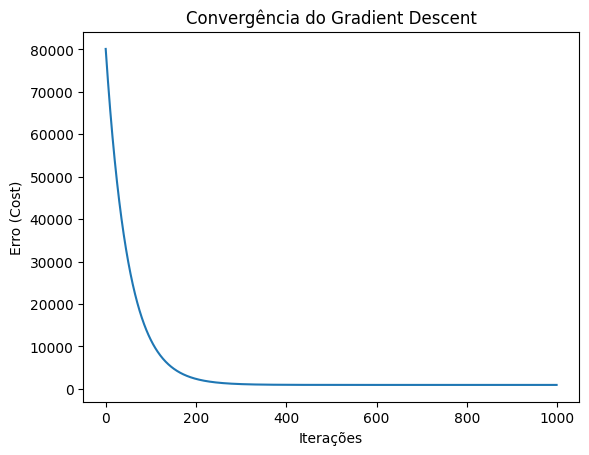

In [92]:
#Convergência do modelo
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.xlabel("Iterações")
plt.ylabel("Erro (Cost)")
plt.title("Convergência do Gradient Descent")
plt.show()

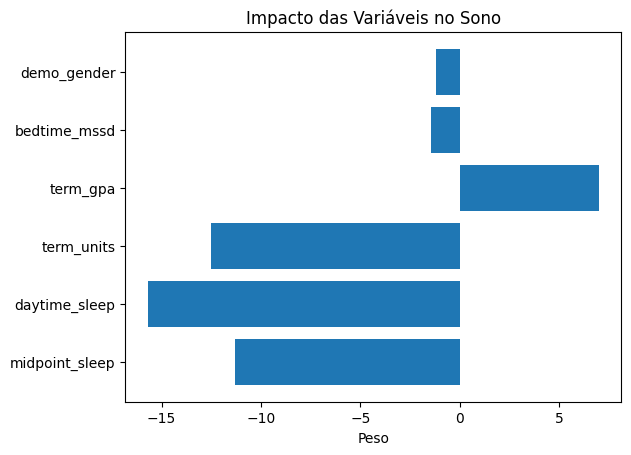

In [93]:
#importancia das variaveis
features = df_model.drop(columns=["TotalSleepTime"]).columns

plt.barh(features, w)
plt.title("Impacto das Variáveis no Sono")
plt.xlabel("Peso")
plt.show()

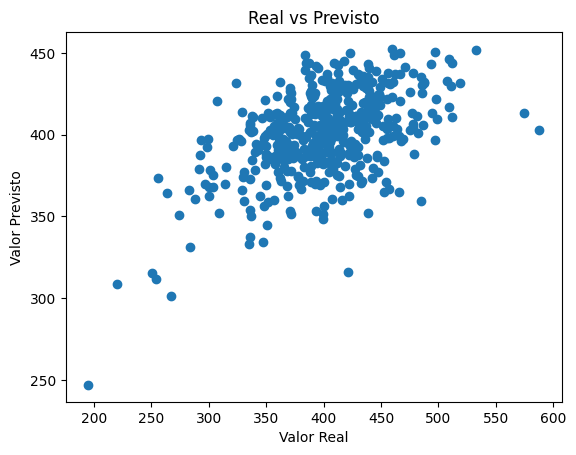

In [94]:
#Previsao x Real
pred = X_norm @ w + b

plt.scatter(y, pred)
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Real vs Previsto")
plt.show()

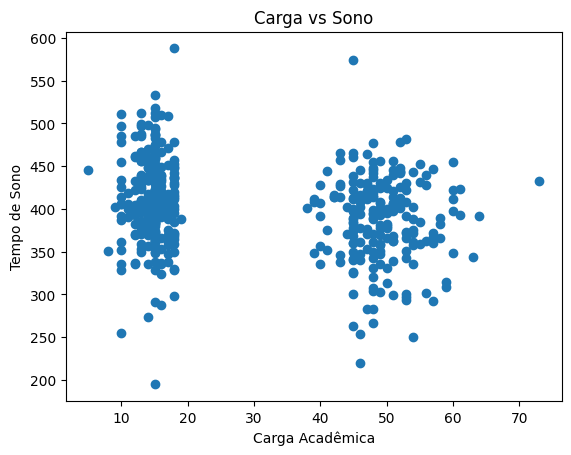

In [95]:
#ANÁLISE POR FEATURE (ISOLADA) Ex: Term Units
plt.scatter(df_model["term_units"], df_model["TotalSleepTime"])
plt.xlabel("Carga Acadêmica")
plt.ylabel("Tempo de Sono")
plt.title("Carga vs Sono")
plt.show()

In [97]:
#Analise por genero 
male = df_model[df_model["demo_gender"] == 0]
female = df_model[df_model["demo_gender"] == 1]

In [98]:
#Compara a media de sono 
print("Sono médio homens:", male["TotalSleepTime"].mean())
print("Sono médio mulheres:", female["TotalSleepTime"].mean())

Sono médio homens: 399.6861608636364
Sono médio mulheres: 401.95820742457914


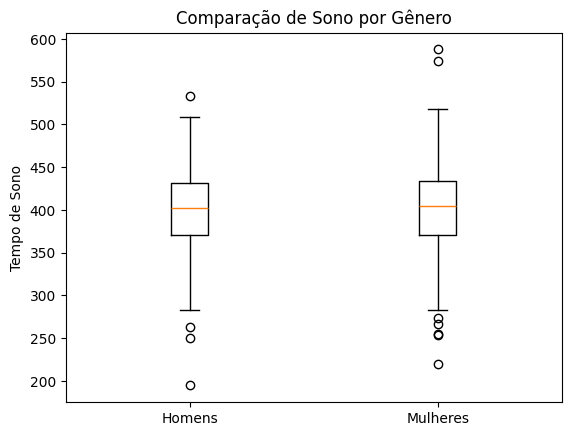

In [100]:
plt.boxplot(
    [
        male["TotalSleepTime"],
        female["TotalSleepTime"]
    ],
    tick_labels=["Homens", "Mulheres"]
)

plt.title("Comparação de Sono por Gênero")
plt.ylabel("Tempo de Sono")
plt.show()

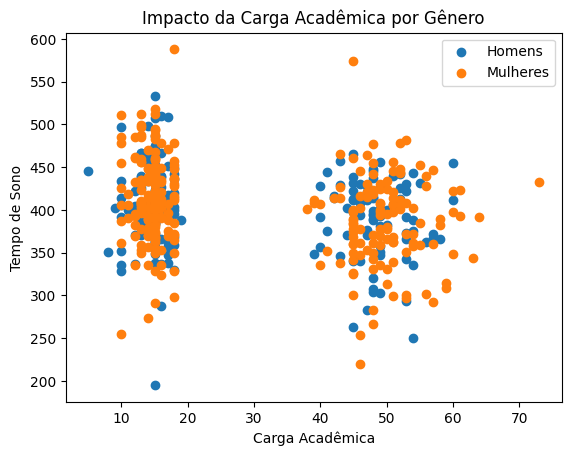

In [101]:
#Features Combinados exemplo carga academica + genero
plt.scatter(male["term_units"], male["TotalSleepTime"], label="Homens")
plt.scatter(female["term_units"], female["TotalSleepTime"], label="Mulheres")

plt.xlabel("Carga Acadêmica")
plt.ylabel("Tempo de Sono")
plt.legend()
plt.title("Impacto da Carga Acadêmica por Gênero")
plt.show()

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# FEATURES USADAS NO MODELO
# =========================

features = df_model.drop(columns=["TotalSleepTime"]).columns

# =========================
# FUNÇÃO PARA PLOTAR A RETA DA REGRESSÃO
# =========================

def plot_regression_line_for_feature(feature_name):
    """
    Plota a relação entre uma feature escolhida e o TotalSleepTime,
    mostrando os pontos reais e a reta prevista pela regressão linear.

    Como o modelo é multivariável, as outras features são mantidas
    constantes na média.
    """

    # Descobrir o índice da feature escolhida
    feature_index = list(features).index(feature_name)

    # Valores reais da feature original
    x_original = df_model[feature_name].values

    # Valores reais do target
    y_real = df_model["TotalSleepTime"].values

    # Criar valores para a feature escolhida, indo do mínimo ao máximo
    x_range_original = np.linspace(
        x_original.min(),
        x_original.max(),
        100
    )

    # Criar uma matriz onde todas as features ficam na média original
    X_plot_original = np.tile(mu, (100, 1))

    # Substituir somente a feature escolhida pelos valores do eixo x
    X_plot_original[:, feature_index] = x_range_original

    # Normalizar usando a mesma média e desvio padrão usados no treino
    X_plot_norm = (X_plot_original - mu) / sigma

    # Calcular a previsão do modelo
    y_pred_line = X_plot_norm @ w + b

    # Plotar os dados reais
    plt.figure(figsize=(8, 5))
    plt.scatter(x_original, y_real, alpha=0.5, label="Dados reais")

    # Plotar a reta da regressão
    plt.plot(x_range_original, y_pred_line, linewidth=2, label="Reta da regressão")

    plt.xlabel(feature_name)
    plt.ylabel("TotalSleepTime")
    plt.title(f"Regressão Linear: {feature_name} vs TotalSleepTime")
    plt.legend()
    plt.grid(True)
    plt.show()

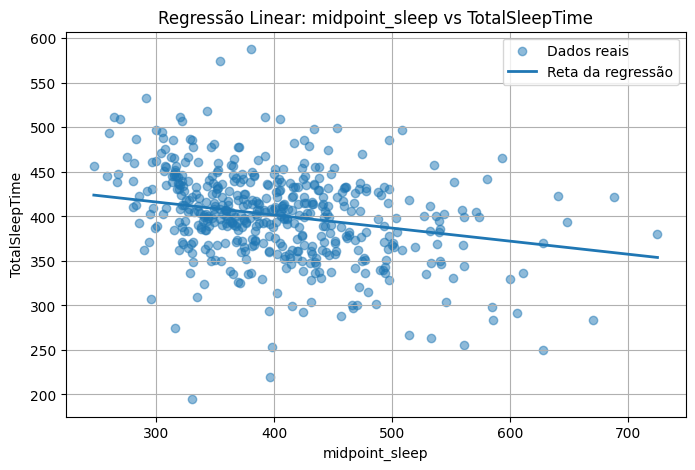

In [104]:
plot_regression_line_for_feature("midpoint_sleep")

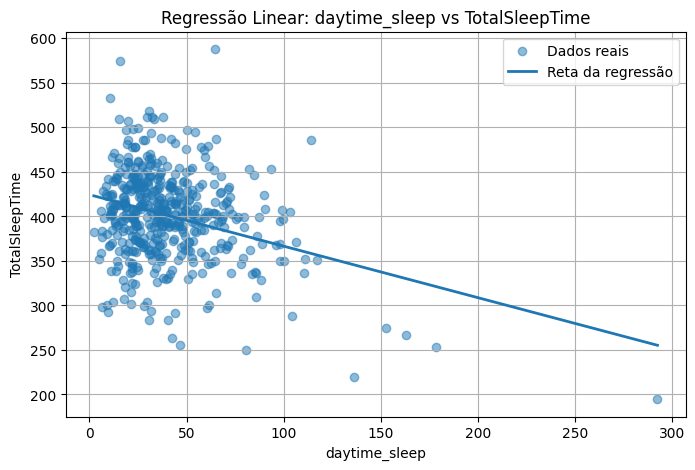

In [105]:
plot_regression_line_for_feature("daytime_sleep")

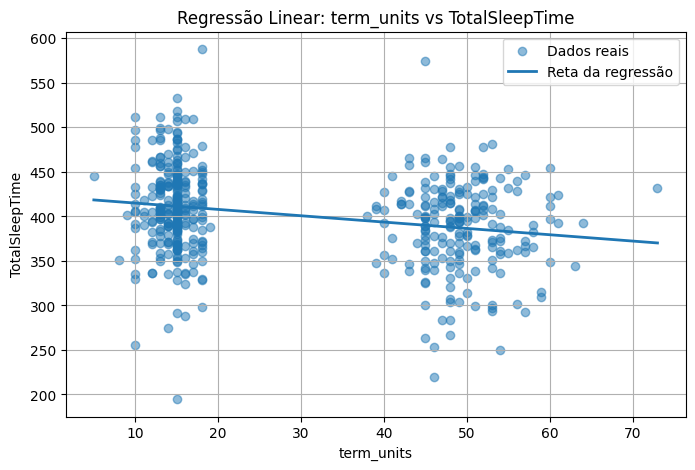

In [107]:
plot_regression_line_for_feature("term_units")

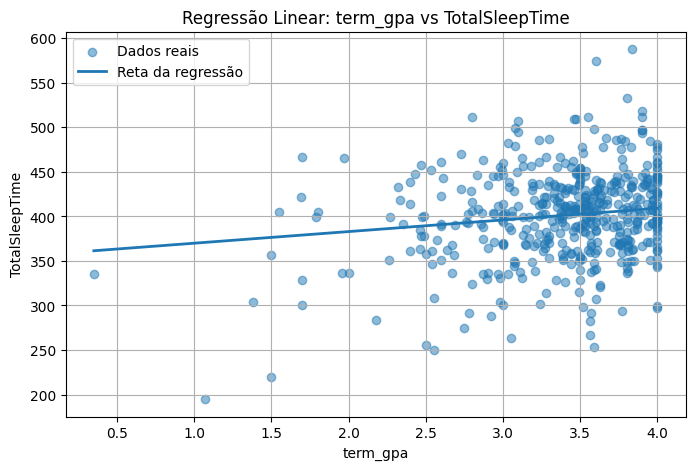

In [108]:
plot_regression_line_for_feature("term_gpa")

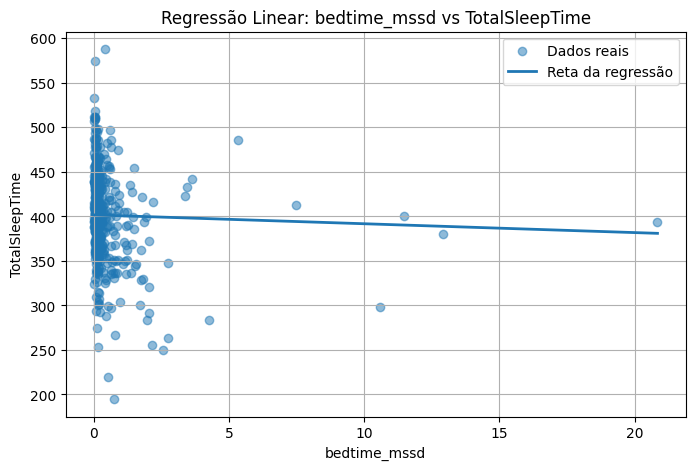

In [109]:
plot_regression_line_for_feature("bedtime_mssd")

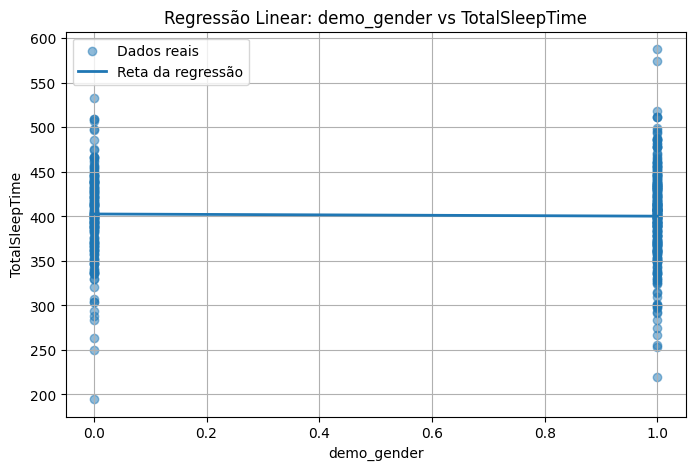

In [110]:
plot_regression_line_for_feature("demo_gender")

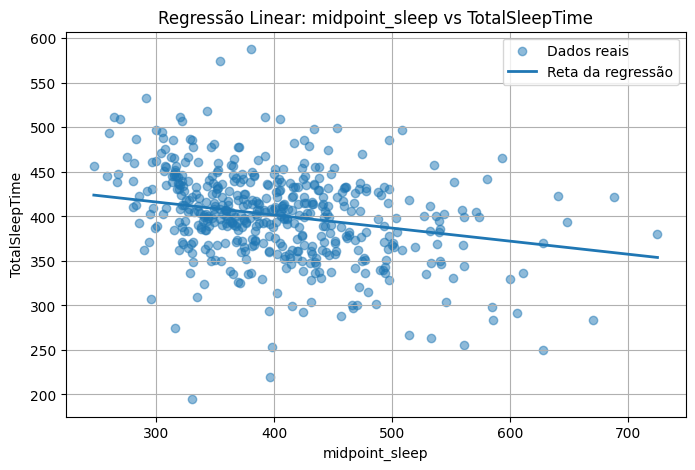

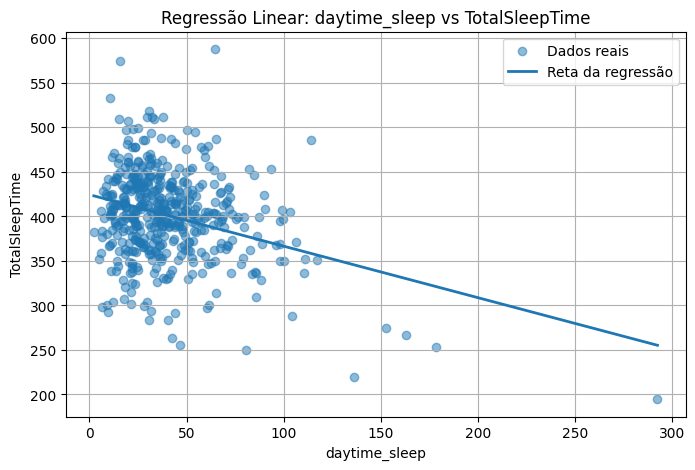

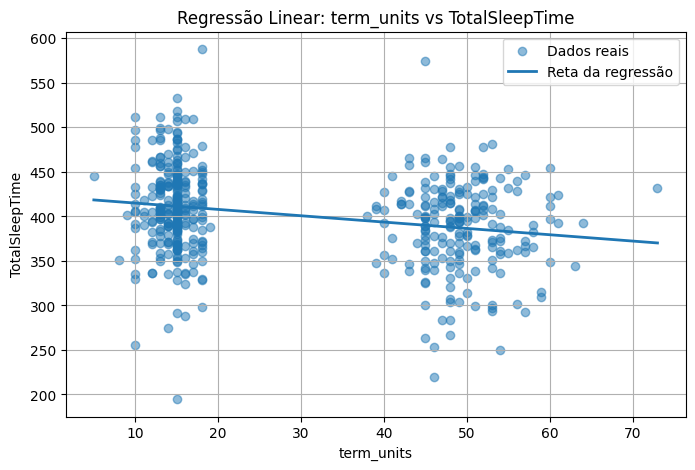

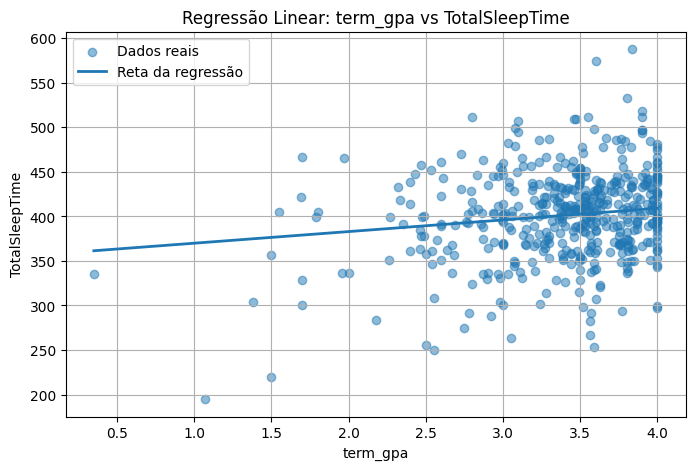

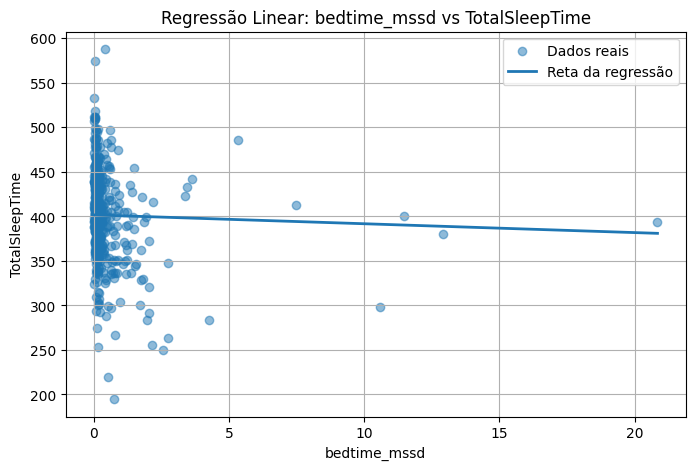

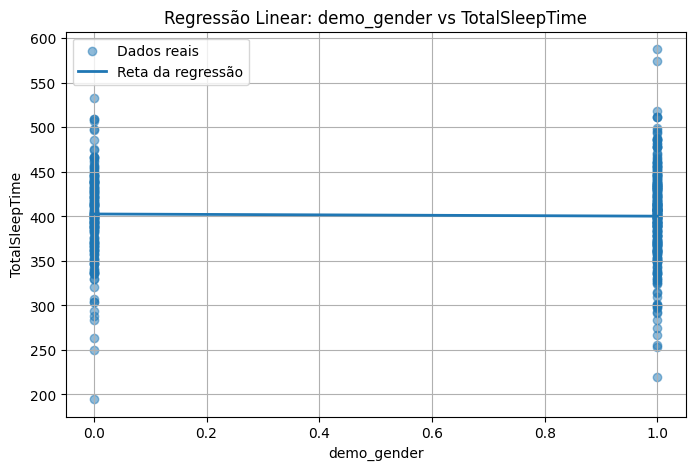

In [111]:
for feature in features:
    plot_regression_line_for_feature(feature)